<a href="https://colab.research.google.com/github/senthil-kumar-7/food-delivery-analytics-project/blob/main/food_delivery_analytics_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import random
import io

# 1. File Upload pandrathukana button uruvakkum
print("Choose Files:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df['TotalAmount'] = df['Quantity'] * df['Price']
df['Hour'] = pd.to_datetime(df['Order_Time']).dt.hour

random.seed(42)
df['OrderStatus'] = [random.choices(['Delivered', 'Cancelled'], weights=[80, 20])[0] for _ in range(len(df))]

print(f"\n✅ Successfully! '{file_name}' uploaded")

Choose Files:


Saving Food Delivery Sales & Customer Insights.csv to Food Delivery Sales & Customer Insights (1).csv

✅ Successfully! 'Food Delivery Sales & Customer Insights (1).csv' uploaded


/tmp/ipykernel_3270/3022163186.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Order_Time']).dt.hour


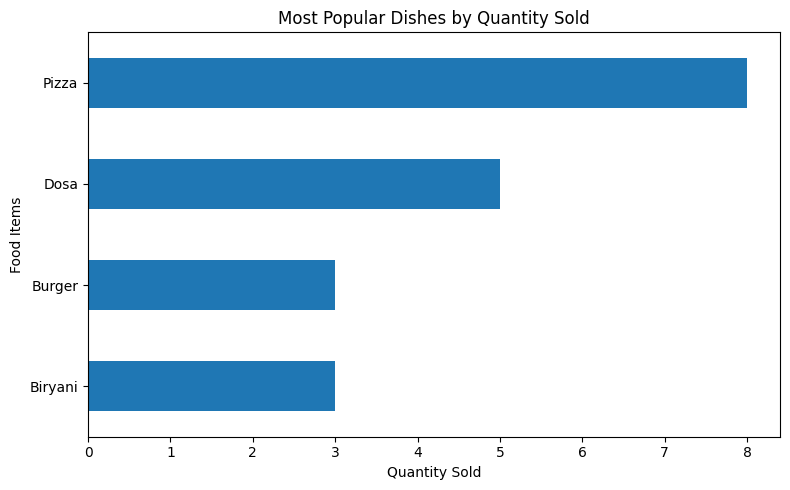

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df.groupby('Item')['Quantity'].sum().sort_values(ascending=True).plot(
    kind='barh',
    color='#1f77b4',
    title='Most Popular Dishes by Quantity Sold'
)
plt.xlabel('Quantity Sold')
plt.ylabel('Food Items')
plt.tight_layout()
plt.show()

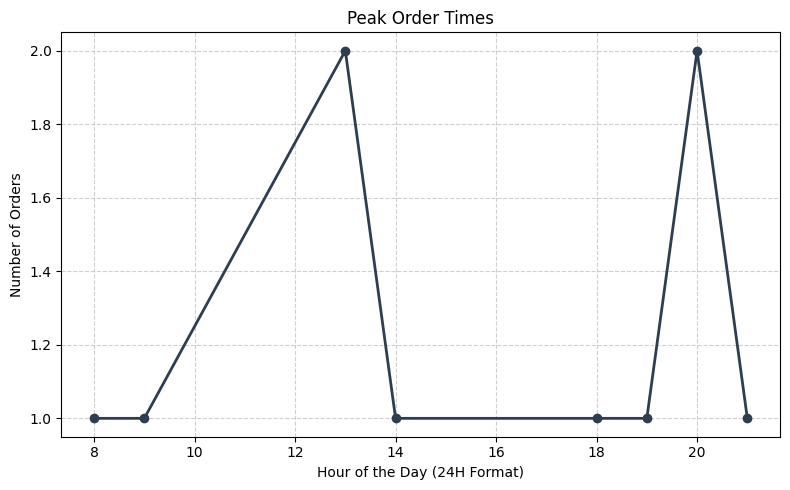

In [ ]:
plt.figure(figsize=(8, 5))
df['Hour'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    color='#2c3e50',
    linewidth=2,
    title='Peak Order Times'
)
plt.xlabel('Hour of the Day (24H Format)')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

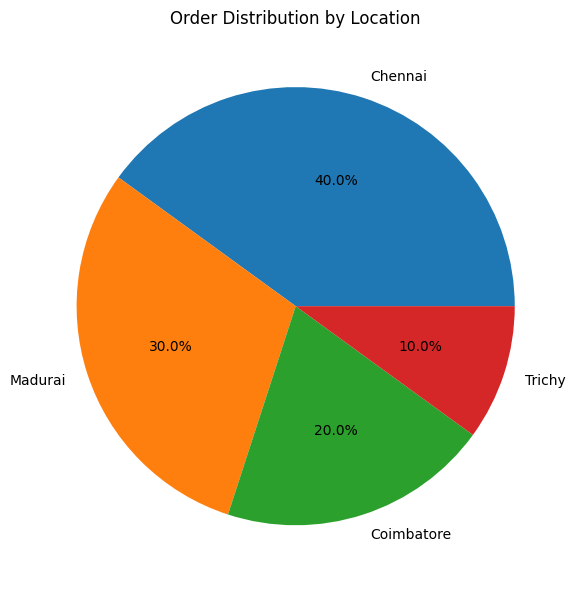

In [ ]:
standard_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(6, 6))
df['Location'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=standard_colors,
    title='Order Distribution by Location'
)
plt.ylabel('')
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

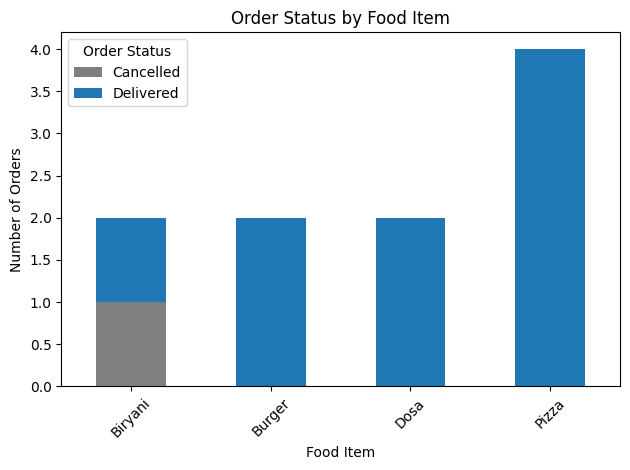

In [ ]:
plt.figure(figsize=(9, 5))
df.groupby(['Item', 'OrderStatus']).size().unstack().fillna(0).plot(
    kind='bar',
    stacked=True,
    color=['#7f7f7f', '#1f77b4'],
    title='Order Status by Food Item'
)
plt.xlabel('Food Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()

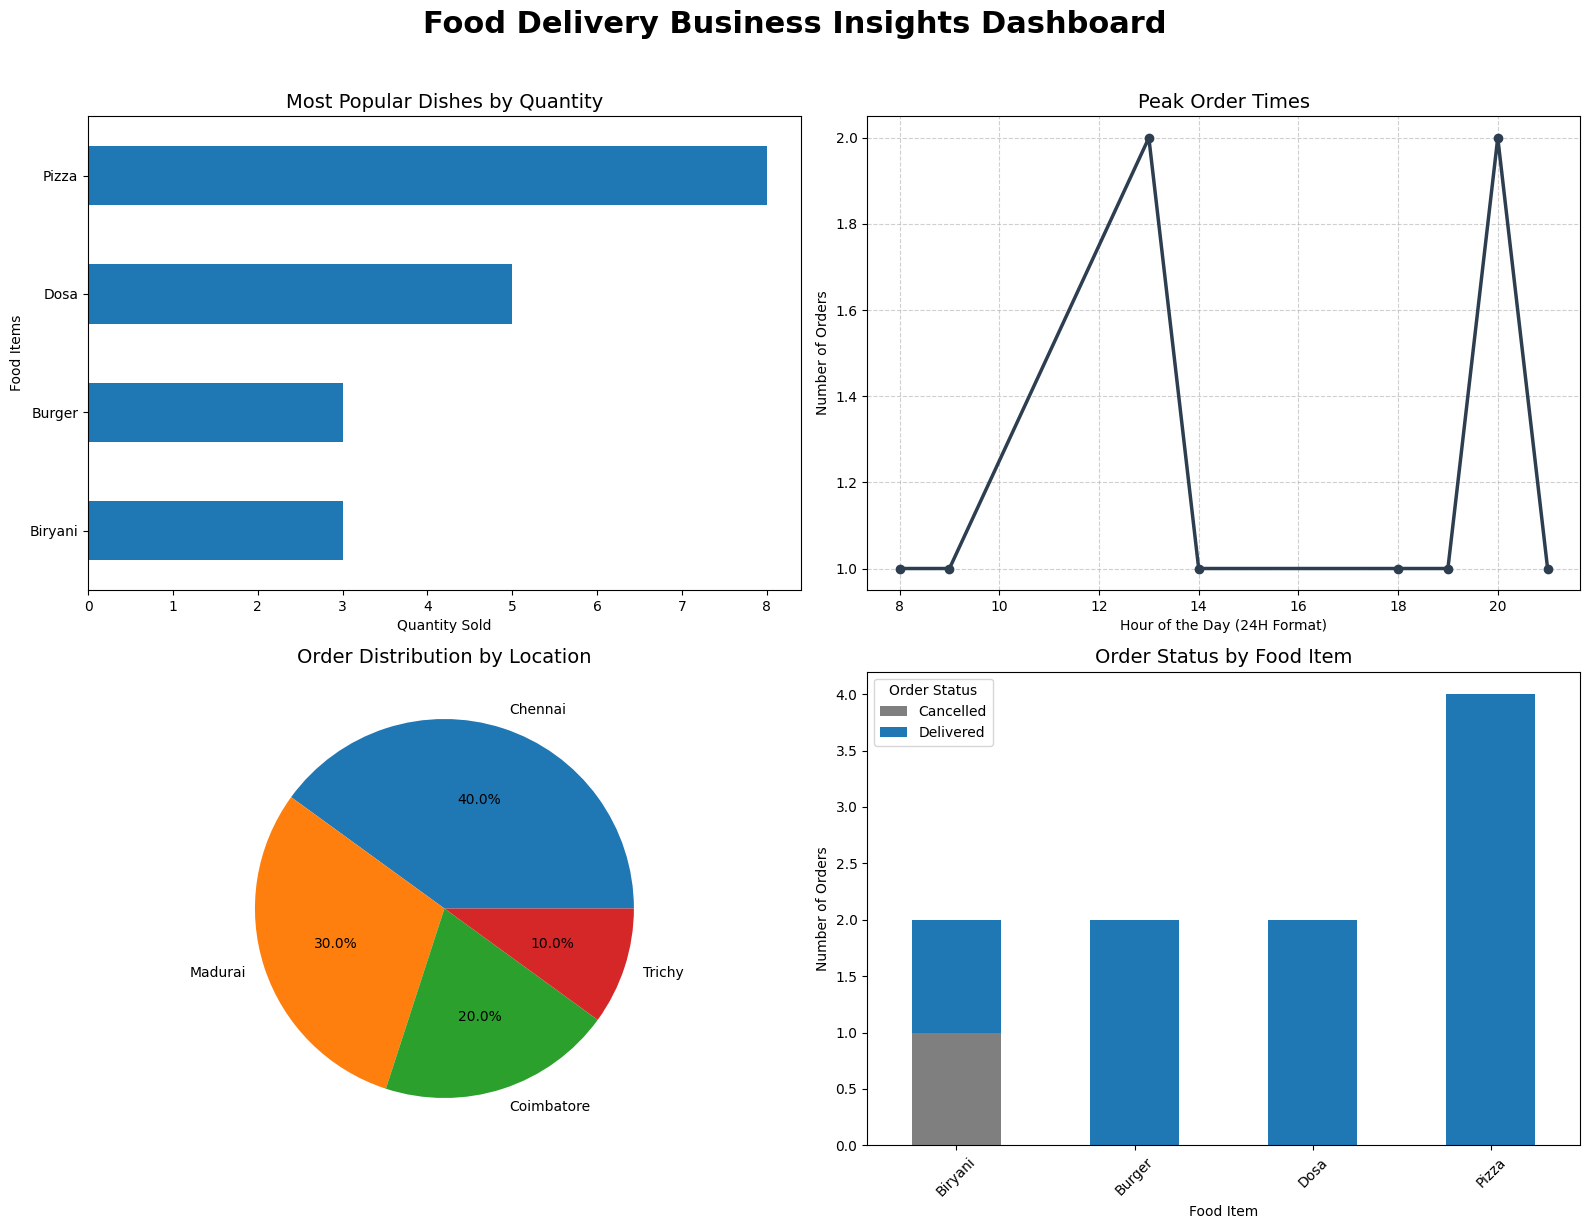